In [1]:
# pip install git+https://github.com/facebookresearch/segment-anything.git
# pip install opencv-python matplotlib
# pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

In [13]:
# wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
# wget https://github.com/IDEA‑Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth


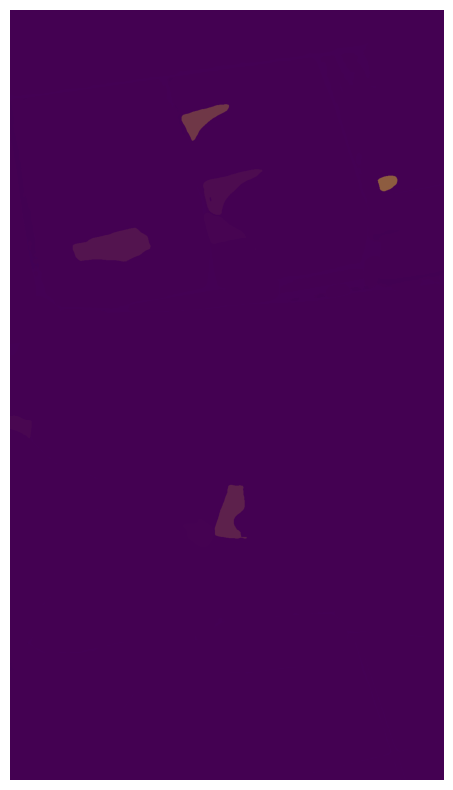

In [1]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# === EDIT THESE ===
CHECKPOINT = "sam_vit_h_4b8939.pth"  # download this if you haven’t yet
MODEL_TYPE = "vit_h"                 # choose model size
IMAGE_PATH  = "/home/ubuntu/additional_drive/shwan_data/scripts/all_frames/cinnamon_rolls__888109010164__4/cinnamon_rolls__888109010164__4_frame_001.png"
# ==============

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load SAM model
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT)
sam.to(device=device)
sam.eval()

# Create automatic mask generator
mask_generator = SamAutomaticMaskGenerator(sam)

# Load image
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Generate masks for all objects in image
masks_info = mask_generator.generate(image_rgb)  # returns list of dicts including ‘segmentation’ etc. :contentReference[oaicite:2]{index=2}

# Visualize overlays
plt.figure(figsize=(10,10))
plt.imshow(image_rgb)
for mask_dict in masks_info:
    mask = mask_dict["segmentation"]  # boolean mask
    plt.imshow(mask, alpha=0.4)       # overlay each mask semi‑transparent
plt.axis("off")
plt.show()


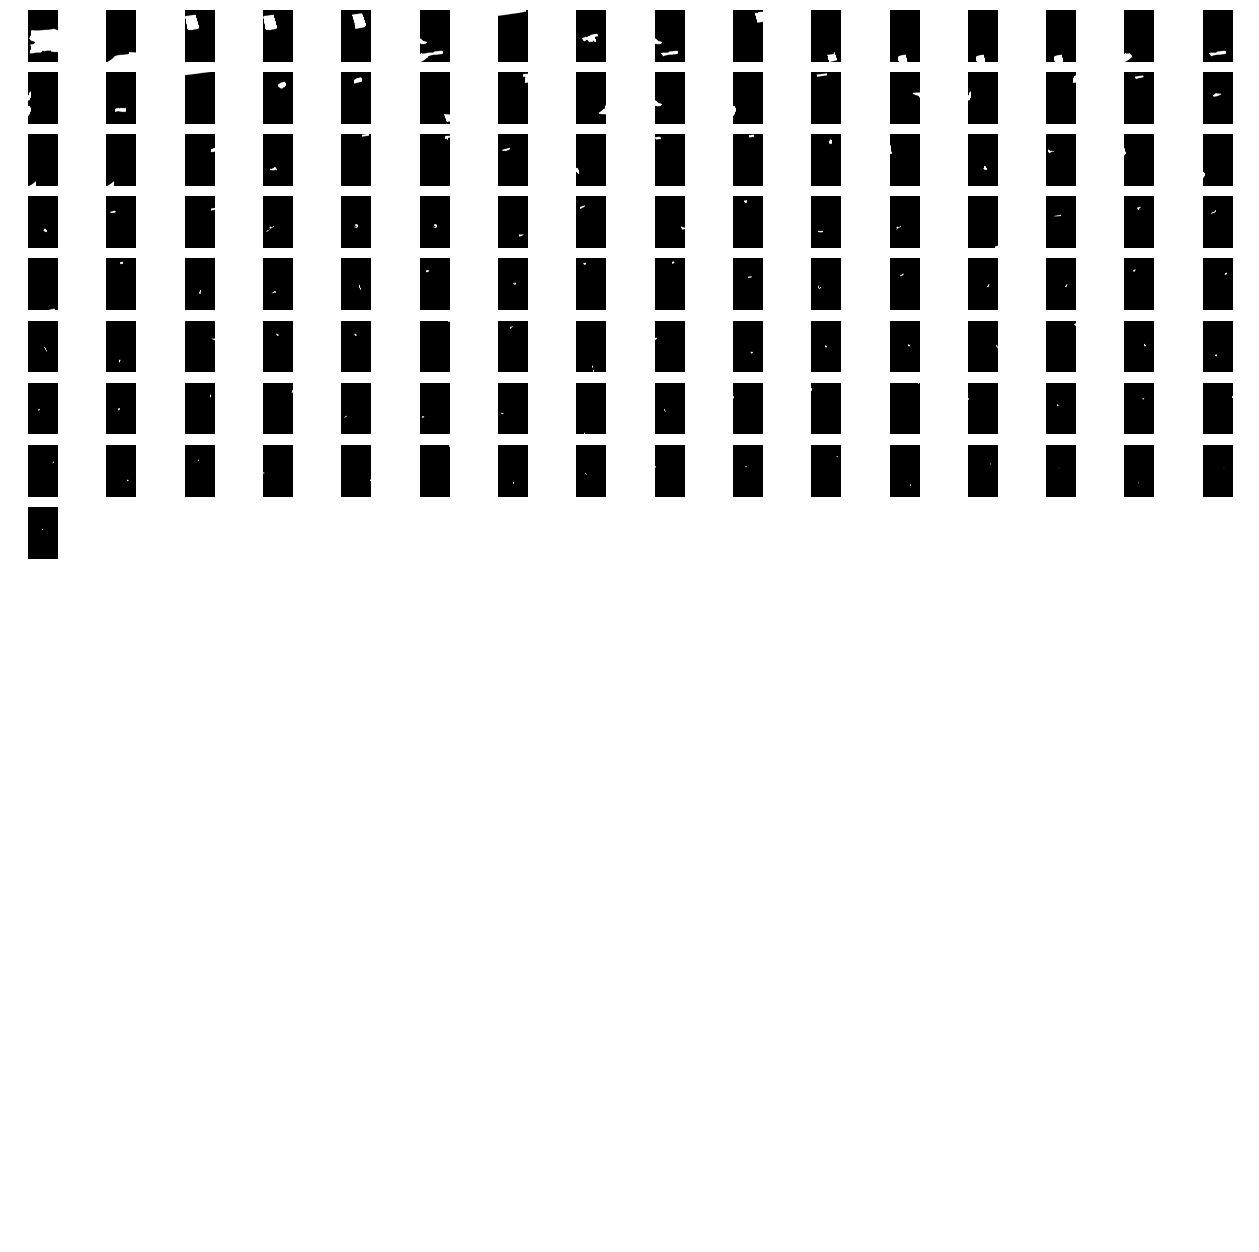

In [11]:
import cv2
import supervision as sv

masks = [
    mask['segmentation']
    for mask
    in sorted(masks_info, key=lambda x: x['area'], reverse=True)
]

sv.plot_images_grid(
    images=masks,
    grid_size=(20, int(len(masks) / 8)),
    size=(16, 16)
)

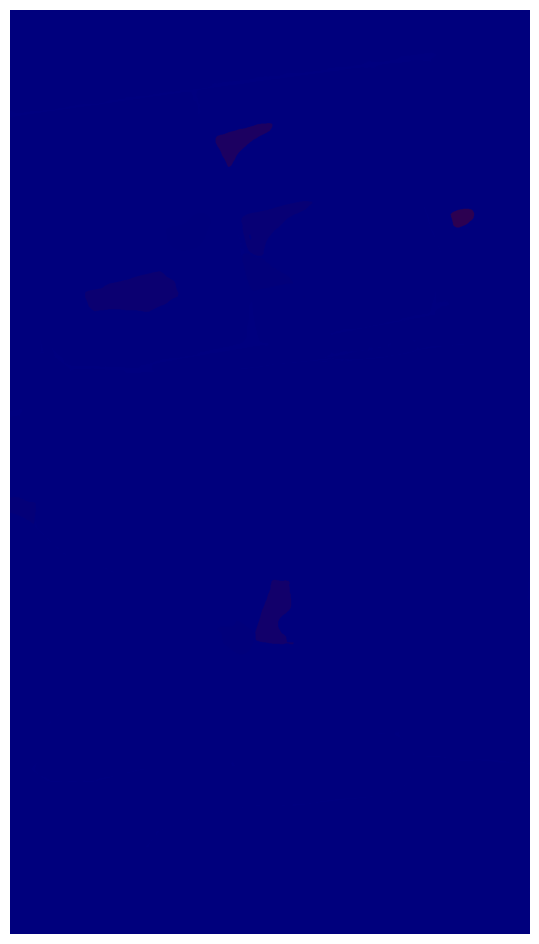

In [12]:
# Visualize image + each mask overlay
plt.figure(figsize=(12,12))
plt.imshow(image_rgb)
for mask_dict in masks_info:
    mask = mask_dict["segmentation"]   # boolean array
    plt.imshow(mask, alpha=0.35, cmap="jet")
plt.axis("off")
plt.show()


In [15]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# Grounding DINO imports
from groundingdino.util.inference import load_model as load_gdino_model, run_inference as gdino_predict

# SAM imports
from segment_anything import sam_model_registry, SamPredictor

ModuleNotFoundError: No module named 'groundingdino'

In [ ]:
from g